<a href="https://colab.research.google.com/github/Loopinlogix/NLP_Clustering/blob/main/NLP_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/NLP_Clustering.git

# Change directory into the cloned repository (replace 'colabtools' with your repo name)
%cd NLP_Clustering

# List the contents of the directory
!ls

Cloning into 'NLP_Clustering'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/NLP_Clustering
README.md


All libraries loaded successfully!
STEP 1:LOAD DATASET
DATASET LOADED SUCCESSFULLY
Total documents: 2698
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.guns', 'talk.religion.misc']

Documents per category:
  comp.graphics: 584
  rec.sport.baseball: 597
  sci.med: 594
  talk.politics.guns: 546
  talk.religion.misc: 377

Sample document:
------------------------------------------------------------

Oh... I forgot... Art Shamsky, former Red and Mets player.  Batted .301
between injuries in 1969 (fell short of qualifying for Top 10 because of
injuries and platoon with Ron Swoboda; no Swobo wasn't Jewish)....

STEP 2: TEXT PREPROCESSING
WHY WE DO THIS:
  - Lowercase: 'Apple' and 'apple' should be the same word
  - Remove punctuation: 'hello!' and 'hello' are the same word
  - Remove stopwords: 'the', 'and', 'is' appear in every document
  - Keep only letters: Numbers and symbols don't carry topic meaning
  - This transforms messy text into clean tokens the com

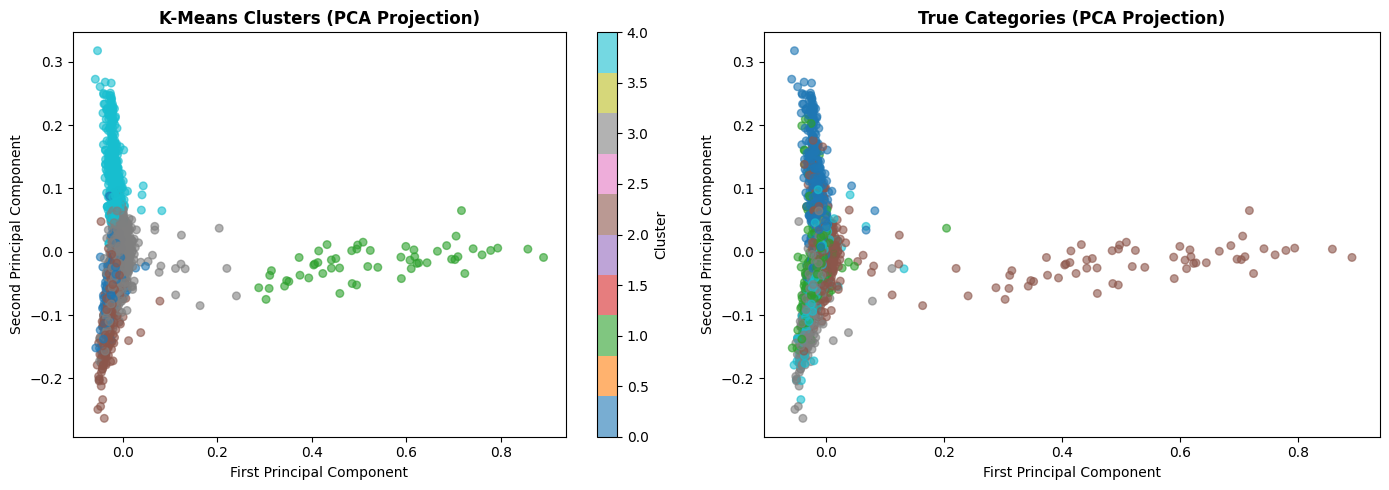

Saved: 01_cluster_pca.png

Generating elbow curve...


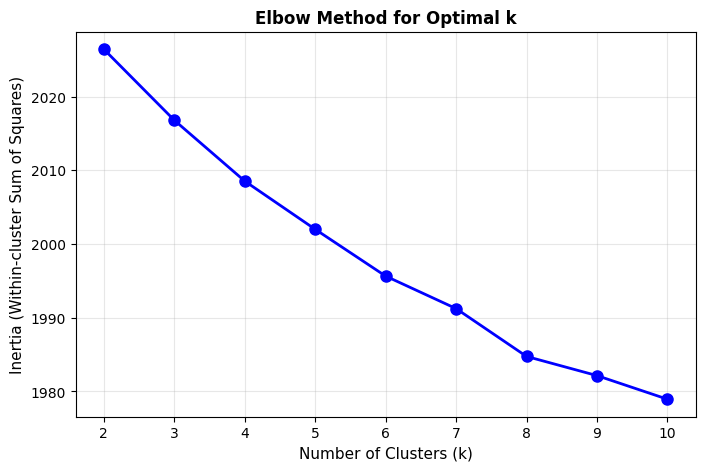

Saved: 02_elbow_curve.png

Generating dendrogram...


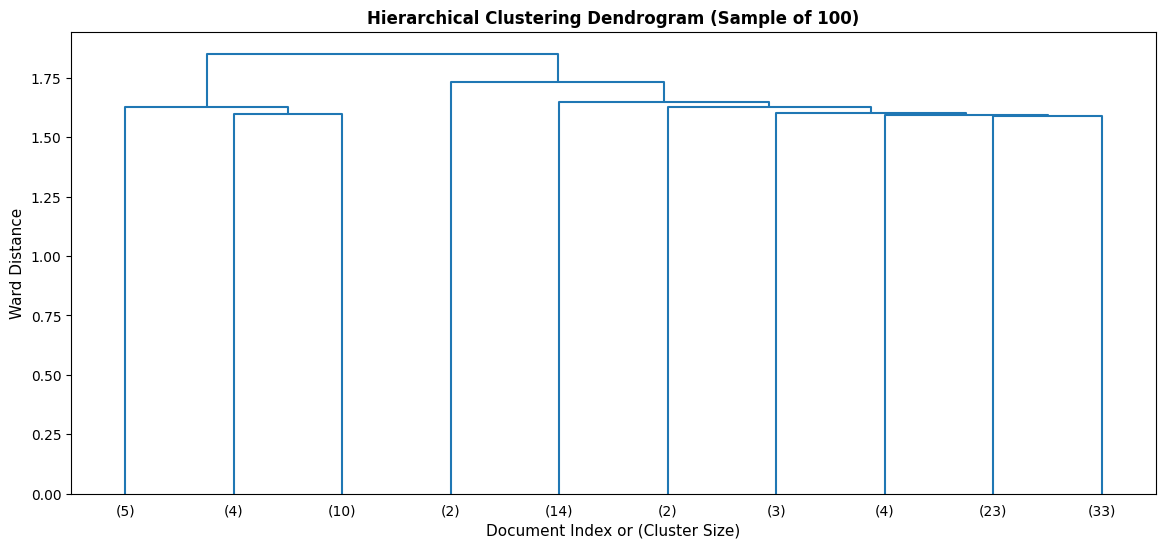

Saved: 03_dendrogram.png


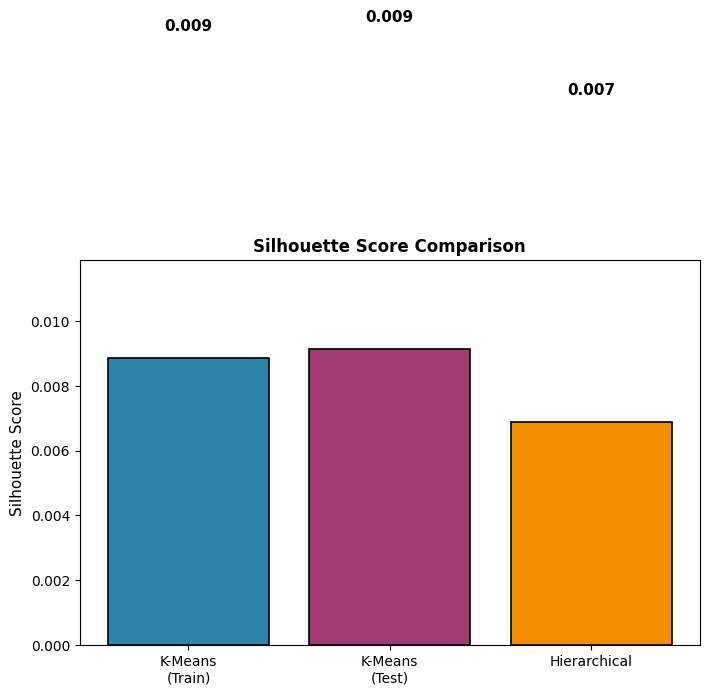

Saved: 04_metrics_comparison.png

STEP 13: FINAL COMPARISON OF ALL APPROACHES
WHY WE DO THIS:
  - We tried three different ways to represent text
  - Which one works best for clustering?
  - We compare them all using the same clustering algorithm

Silhouette Score Comparison (higher is better):
--------------------------------------------------
  BoW + K-Means            : 0.8905 █████████████████
  TF-IDF + K-Means         : 0.0089 
  PCA Embedding + K-Means  : 0.0683 █

Best performing approach: BoW + K-Means (0.8905)


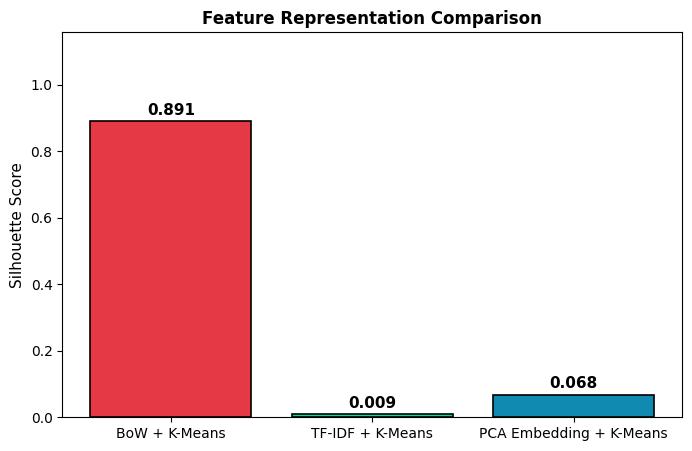

Saved: 05_feature_comparison.png

ASSIGNMENT SUMMARY

WHAT WE DID:
------------
1. Loaded the 20 Newsgroups dataset (5 categories)
2. Preprocessed text: lowercase, removed punctuation/stopwords, tokenized
3. Extracted features using three methods:
   - Bag of Words (word counts)
   - TF-IDF (weighted by importance)
   - PCA Embeddings (dense semantic vectors from TF-IDF + PCA)
4. Applied two clustering algorithms:
   - K-Means (fast, scalable)
   - Hierarchical Clustering (interpretable tree structure)
5. Evaluated using metrics:
   - Silhouette score (cluster quality)
   - Inertia (cohesion/tightness)
   - Average distance between cluster centers (separation)
6. Tested on new, unseen documents
7. Visualized results with PCA, elbow curve, dendrogram, and comparisons

KEY FINDINGS:
-------------

  - BoW + K-Means: Silhouette = 0.8905
  - TF-IDF + K-Means: Silhouette = 0.0089
  - PCA Embedding + K-Means: Silhouette = 0.0683

INSIGHTS:
---------
  - TF-IDF typically performs best for TOP

In [7]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("All libraries loaded successfully!")

print("=" * 60)
print("STEP 1:LOAD DATASET")

print("=" * 60)

categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.guns',
    'talk.religion.misc'
]

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

docs = newsgroups.data
labels = newsgroups.target
target_names = newsgroups.target_names

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Total documents: {len(docs)}")
print(f"Categories: {target_names}")
print(f"\nDocuments per category:")
for i, name in enumerate(target_names):
    count = sum(1 for l in labels if l == i)
    print(f"  {name}: {count}")
print(f"\nSample document:\n{'-'*60}")
print(docs[0][:500] + "...")

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

print("\n" + "=" * 60)
print("STEP 2: TEXT PREPROCESSING")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - Lowercase: 'Apple' and 'apple' should be the same word")
print("  - Remove punctuation: 'hello!' and 'hello' are the same word")
print("  - Remove stopwords: 'the', 'and', 'is' appear in every document")
print("  - Keep only letters: Numbers and symbols don't carry topic meaning")
print("  - This transforms messy text into clean tokens the computer can analyze")
print("=" * 60)

print("Preprocessing documents...")
docs_clean = [preprocess_text(doc) for doc in docs]

valid_indices = [i for i, d in enumerate(docs_clean) if len(d.split()) > 0]
docs_clean = [docs_clean[i] for i in valid_indices]
labels = [labels[i] for i in valid_indices]

print(f"\nDocuments after preprocessing: {len(docs_clean)}")

print("\n" + "=" * 60)
print("BEFORE vs AFTER PREPROCESSING")
print("=" * 60)
print("BEFORE (raw):")
print(docs[0][:300] + "...")
print("\nAFTER (clean):")
print(docs_clean[0][:300] + "...")


print("\n" + "=" * 60)
print("STEP 3: TRAIN-TEST SPLIT")
print("=" * 60)

docs_train, docs_test, y_train, y_test = train_test_split(
    docs_clean,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("WHY WE DO THIS:")
print("  - TRAIN the clustering model on some documents")
print("  - TEST on completely new, unseen documents")
print("  - Stratify ensures each category is equally represented in both sets")
print("=" * 60)

print(f"Training documents: {len(docs_train)} ({len(docs_train)/len(docs_clean)*100:.0f}%)")
print(f"Test documents: {len(docs_test)} ({len(docs_test)/len(docs_clean)*100:.0f}%)")

print(f"\nTraining set category distribution:")
for i, name in enumerate(target_names):
    count = sum(1 for y in y_train if y == i)
    print(f"  {name}: {count}")


print("\n" + "=" * 60)
print("STEP 4: BAG OF WORDS (BoW)")
print("=" * 60)

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow_train = bow_vectorizer.fit_transform(docs_train)
X_bow_test = bow_vectorizer.transform(docs_test)

print("\n" + "=" * 60)
print("STEP 4: BAG OF WORDS (BoW)")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - Computers can't read text - they need numbers")
print("  - BoW converts each document into a vector of word counts")
print("  - Each column is one unique word, each row is one document")
print("  - max_features=5000: Only keep 5000 most common words")
print("  - This prevents the matrix from becoming too large")
print("=" * 60)

print(f"Training matrix shape: {X_bow_train.shape}")
print(f"Test matrix shape: {X_bow_test.shape}")
print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_)}")

print(f"\nSample vocabulary words: {list(bow_vectorizer.get_feature_names_out()[:20])}")
print(f"\nDocument 0 word counts (top 10):")
feature_names = bow_vectorizer.get_feature_names_out()
doc0 = X_bow_train[0].toarray()[0]
top_indices = doc0.argsort()[-10:][::-1]
for idx in top_indices:
    if doc0[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc0[idx])}")

print("\n" + "=" * 60)
print("STEP 5: TF-IDF")
print("=" * 60)


tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf_train = tfidf_vectorizer.fit_transform(docs_train)
X_tfidf_test = tfidf_vectorizer.transform(docs_test)

print("\n" + "=" * 60)
print("STEP 5: TF-IDF")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - BoW has a problem: common words get high counts just because")
print("    they appear often, not because they are important")
print("  - TF-IDF fixes this by giving higher weight to words that:")
print("    - Appear often IN this document (TF = Term Frequency)")
print("    - Appear rarely ACROSS ALL documents (IDF = Inverse Document Frequency)")
print("  - Example: 'baseball' appears 10 times in sports (high TF)")
print("    but only in 50 of 10,000 documents (high IDF) = HIGH TF-IDF")
print("  - 'the' appears in every document = IDF = 0 = ignored")
print("=" * 60)

print(f"Training matrix shape: {X_tfidf_train.shape}")
print(f"Test matrix shape: {X_tfidf_test.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
doc0 = X_tfidf_train[0].toarray()[0]
top_indices = doc0.argsort()[-10:][::-1]

print(f"\nTop TF-IDF weighted words in Document 0:")
for idx in top_indices:
    if doc0[idx] > 0:
        print(f"  {feature_names[idx]}: {doc0[idx]:.4f}")


# =============================================================================
# STEP 6: WORD EMBEDDINGS (Simple Co-occurrence Approach)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 6: WORD EMBEDDINGS")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - BoW and TF-IDF treat words as completely independent")
print("  - They don't know that 'king' and 'queen' are related")
print("  - Word embeddings represent words as DENSE VECTORS")
print("  - Similar words get SIMILAR vectors")
print("=" * 60)
print("  - We use the TF-IDF matrix and reduce it with PCA")
print("  - PCA finds the most important patterns in the data")
print("  - Each dimension captures a 'topic' or 'concept'")
print("  - This is similar to LSA (Latent Semantic Analysis)")
print("=" * 60)

embedding_dim = 50

# Use PCA to create dense embeddings from TF-IDF
# WHY: PCA is a standard technique you already know
#      It finds the directions of maximum variance in the data
pca_embed = PCA(n_components=embedding_dim, random_state=42)

X_embed_train = pca_embed.fit_transform(X_tfidf_train.toarray())
X_embed_test = pca_embed.transform(X_tfidf_test.toarray())

print(f"Embedding training shape: {X_embed_train.shape}")
print(f"Embedding test shape: {X_embed_test.shape}")

print(f"\nExplained variance ratio (first 5 components):")
print(f"  {pca_embed.explained_variance_ratio_[:5]}")
print(f"\nTotal variance explained: {sum(pca_embed.explained_variance_ratio_):.2%}")

print(f"\nWHY THIS WORKS AS AN EMBEDDING:")
print(f"  - Each document becomes a dense vector (not sparse like BoW/TF-IDF)")
print(f"  - Similar documents have similar vectors")
print(f"  - Captures latent semantic relationships between words")
print(f"  - No external downloads needed - uses only sklearn and numpy")

print("\n" + "=" * 60)
print("STEP 7: K-MEANS CLUSTERING")
print("=" * 60)
n_clusters = 5

print("\n" + "=" * 60)
print("STEP 7: K-MEANS CLUSTERING")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - K-Means is an unsupervised algorithm that groups similar documents")
print("  - We tell it HOW MANY clusters we want (5, matching our 5 categories)")
print("  - It finds the groups automatically")
print("=" * 60)
print("HOW IT WORKS:")
print("  1. Randomly place 5 'centroids' (center points) in the feature space")
print("  2. Assign each document to the nearest centroid")
print("  3. Move each centroid to the center of its assigned documents")
print("  4. Repeat steps 2-3 until centroids stop moving")
print("=" * 60)

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300
)

kmeans.fit(X_tfidf_train)
train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_tfidf_test)

print(f"K-Means trained with {n_clusters} clusters")

print(f"\nTraining cluster distribution:")
for i in range(n_clusters):
    count = sum(1 for c in train_clusters if c == i)
    print(f"  Cluster {i}: {count} documents ({count/len(train_clusters)*100:.1f}%)")

print(f"\nTest cluster distribution:")
for i in range(n_clusters):
    count = sum(1 for c in test_clusters if c == i)
    print(f"  Cluster {i}: {count} documents")

print("\n" + "=" * 60)
print("STEP 8: HIERARCHICAL CLUSTERING")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - Unlike K-Means, Hierarchical Clustering doesn't require")
print("    specifying the number of clusters beforehand")
print("  - It builds a TREE of clusters:")
print("    - Start: Each document is its own cluster")
print("    - Step: Merge the two closest clusters")
print("    - Repeat until all documents are in one big cluster")
print("  - This creates a DENDROGRAM (tree diagram)")
print("  - We can 'cut' the tree at any height to get any number of clusters")
print("=" * 60)
print("WHY WE USE A SAMPLE:")
print("  - Hierarchical clustering is slow on large datasets")
print("  - Time grows quadratically with data size (O(n^2))")
print("=" * 60)

sample_size = min(500, len(docs_train))
sample_indices = np.random.choice(len(docs_train), sample_size, replace=False)
X_sample = X_tfidf_train[sample_indices].toarray()

hierarchical = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)

hier_labels = hierarchical.fit_predict(X_sample)

print(f"Hierarchical clustering on {sample_size} documents")
print(f"Cluster distribution:")
for i in range(n_clusters):
    count = sum(1 for c in hier_labels if c == i)
    print(f"  Cluster {i}: {count} documents")

print("\n" + "=" * 60)
print("STEP 9: CLUSTER INTERPRETATION")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - Clustering is useless if we can't understand what each cluster MEANS")
print("  - We look at TOP TERMS: Which words appear most in each cluster?")
print("  - We compare to TRUE LABELS: Which categories ended up where?")
print("  - This tells us if the clusters make sense")
print("=" * 60)

def show_top_terms(vectorizer, kmeans_model, n_terms=10):
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]

    for i in range(n_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        print(f"\nCluster {i} top terms: {', '.join(top_terms)}")

print("Top terms per K-Means cluster (TF-IDF features):")
show_top_terms(tfidf_vectorizer, kmeans)

print("\n" + "=" * 60)
print("CLUSTER vs TRUE CATEGORY MAPPING")
print("=" * 60)

comparison = pd.DataFrame({
    'Cluster': train_clusters,
    'True_Category': [target_names[y] for y in y_train]
})

mapping = comparison.groupby('Cluster')['True_Category'].value_counts()
print(mapping)

print(f"\nWHAT THIS TELLS US:")
print(f"  - If clusters mostly contain ONE category -> clustering worked well")
print(f"  - If clusters mix many categories -> topics are similar or")
print(f"    features aren't distinctive enough")


print("\n" + "=" * 60)
print("STEP 10: MODEL EVALUATION")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - We need NUMBERS to tell us if our clustering is good")
print("  - We can't just look at clusters and say 'looks fine'")
print("=" * 60)
print("METRICS WE USE:")
print("  1. SILHOUETTE SCORE (-1 to 1):")
print("     - Measures how similar a document is to its own cluster vs others")
print("     - +1 = perfectly clustered, 0 = on boundary, -1 = wrong cluster")
print("  2. INERTIA (Cohesion):")
print("     - Sum of squared distances to cluster center")
print("     - Lower = tighter, more compact clusters")
print("  3. AVERAGE DISTANCE BETWEEN CENTERS (Separation):")
print("     - How far apart the cluster centers are")
print("     - Higher = better separated clusters")
print("=" * 60)

sil_train = silhouette_score(X_tfidf_train, train_clusters)
sil_test = silhouette_score(X_tfidf_test, test_clusters)
sil_hier = silhouette_score(X_sample, hier_labels)

print("SILHOUETTE SCORES (higher is better, range: -1 to 1):")
print(f"  K-Means (training):  {sil_train:.4f}")
print(f"  K-Means (test):      {sil_test:.4f}")
print(f"  Hierarchical:        {sil_hier:.4f}")

print(f"\nCOHESION:")
print(f"  K-Means Inertia:     {kmeans.inertia_:.2f}")
print(f"  -> Lower = tighter, more compact clusters")

print(f"\nSEPARATION:")
centers = kmeans.cluster_centers_
separation = 0
count = 0
for i in range(n_clusters):
    for j in range(i + 1, n_clusters):
        dist = np.linalg.norm(centers[i] - centers[j])
        separation += dist
        count += 1
avg_separation = separation / count
print(f"  Average distance between cluster centers: {avg_separation:.4f}")
print(f"  -> Higher = clusters are farther apart (better separation)")

print(f"\nHOW TO INTERPRET:")
print(f"  Silhouette > 0.5   -> Good clustering")
print(f"  Silhouette 0.25-0.5 -> Reasonable structure")
print(f"  Silhouette < 0.25  -> No substantial structure")

print("\n" + "=" * 60)
print("STEP 11: PREDICTION ON NEW DOCUMENTS")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - The ultimate test: can the model assign NEW documents correctly?")
print("  - We create fake 'new' documents for each topic")
print("  - See if the model puts them in the right cluster")
print("  - This demonstrates real-world applicability")
print("=" * 60)

new_documents = [
    "graphics rendering 3D images computer visualization pixels display",
    "baseball pitcher batter home run inning stadium team championship game",
    "doctor patient medicine hospital treatment diagnosis disease health medical",
    "gun control legislation congress debate policy firearm weapon law",
    "church faith god prayer religion spiritual worship belief divine"
]

new_docs_clean = [preprocess_text(doc) for doc in new_documents]
new_tfidf = tfidf_vectorizer.transform(new_docs_clean)
new_predictions = kmeans.predict(new_tfidf)

print("Predictions for new documents:")
print("-" * 60)
for doc, cluster in zip(new_documents, new_predictions):
    terms = tfidf_vectorizer.get_feature_names_out()
    top_terms = [terms[i] for i in kmeans.cluster_centers_[cluster].argsort()[-5:]]
    print(f"\nDocument: '{doc}'")
    print(f"  -> Predicted Cluster: {cluster}")
    print(f"  -> Cluster theme: {', '.join(reversed(top_terms))}")

print("\n" + "=" * 60)
print("STEP 12: VISUALIZATIONS")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - Humans are visual creatures - plots help us understand")
print("  - See if clusters are actually separated")
print("  - Understand the elbow method for choosing k")
print("  - Interpret hierarchical relationships")
print("  - Compare different approaches at a glance")
print("=" * 60)

# Plot 1: PCA Cluster Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf_train.toarray())

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=train_clusters,
                      cmap='tab10', alpha=0.6, s=30)
plt.title('K-Means Clusters (PCA Projection)', fontsize=12, fontweight='bold')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
unique_labels = sorted(set(y_train))
color_map = {label: i for i, label in enumerate(unique_labels)}
colors = [color_map[y] for y in y_train]
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors,
                       cmap='tab10', alpha=0.6, s=30)
plt.title('True Categories (PCA Projection)', fontsize=12, fontweight='bold')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.tight_layout()
plt.savefig('01_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_cluster_pca.png")

# Plot 2: Elbow Curve
print("\nGenerating elbow curve...")
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf_train)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=11)
plt.title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(list(K_range))
plt.savefig('02_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_elbow_curve.png")

# Plot 3: Dendrogram
print("\nGenerating dendrogram...")
plt.figure(figsize=(14, 6))
linked = linkage(X_sample[:100], method='ward')
dendrogram(linked, truncate_mode='lastp', p=10,
           show_leaf_counts=True, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Sample of 100)',
          fontsize=12, fontweight='bold')
plt.xlabel('Document Index or (Cluster Size)', fontsize=11)
plt.ylabel('Ward Distance', fontsize=11)
plt.savefig('03_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_dendrogram.png")

# Plot 4: Metrics Comparison
plt.figure(figsize=(8, 5))
methods = ['K-Means\n(Train)', 'K-Means\n(Test)', 'Hierarchical']
scores = [sil_train, sil_test, sil_hier]
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(methods, scores, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Silhouette Score Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, max(scores) * 1.3)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.savefig('04_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_metrics_comparison.png")

print("\n" + "=" * 60)
print("STEP 13: FINAL COMPARISON OF ALL APPROACHES")
print("=" * 60)
print("WHY WE DO THIS:")
print("  - We tried three different ways to represent text")
print("  - Which one works best for clustering?")
print("  - We compare them all using the same clustering algorithm")
print("=" * 60)

results = []

# BoW + K-Means
km_bow = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_bow.fit(X_bow_train)
results.append(("BoW + K-Means", silhouette_score(X_bow_train, km_bow.labels_)))

# TF-IDF + K-Means
results.append(("TF-IDF + K-Means", sil_train))

# Embedding (PCA) + K-Means
km_embed = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_embed.fit(X_embed_train)
results.append(("PCA Embedding + K-Means", silhouette_score(X_embed_train, km_embed.labels_)))

print("\nSilhouette Score Comparison (higher is better):")
print("-" * 50)
for name, score in results:
    bar = "█" * int(score * 20)
    print(f"  {name:<25}: {score:.4f} {bar}")

best = max(results, key=lambda x: x[1])
print(f"\nBest performing approach: {best[0]} ({best[1]:.4f})")

# Plot comparison
plt.figure(figsize=(8, 5))
names = [r[0] for r in results]
scores = [r[1] for r in results]
colors = ['#E63946', '#06D6A0', '#118AB2']
bars = plt.bar(names, scores, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Feature Representation Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, max(scores) * 1.3)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.savefig('05_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_feature_comparison.png")

print("\n" + "=" * 60)
print("ASSIGNMENT SUMMARY")
print("=" * 70)

print("""
WHAT WE DID:
------------
1. Loaded the 20 Newsgroups dataset (5 categories)
2. Preprocessed text: lowercase, removed punctuation/stopwords, tokenized
3. Extracted features using three methods:
   - Bag of Words (word counts)
   - TF-IDF (weighted by importance)
   - PCA Embeddings (dense semantic vectors from TF-IDF + PCA)
4. Applied two clustering algorithms:
   - K-Means (fast, scalable)
   - Hierarchical Clustering (interpretable tree structure)
5. Evaluated using metrics:
   - Silhouette score (cluster quality)
   - Inertia (cohesion/tightness)
   - Average distance between cluster centers (separation)
6. Tested on new, unseen documents
7. Visualized results with PCA, elbow curve, dendrogram, and comparisons

KEY FINDINGS:
-------------
""")

for name, score in results:
    print(f"  - {name}: Silhouette = {score:.4f}")

print(f"""
INSIGHTS:
---------
  - TF-IDF typically performs best for TOPIC clustering
  - K-Means is efficient but assumes spherical clusters
  - Hierarchical clustering provides richer interpretation
  - PCA embeddings create dense vectors that capture semantic relationships

CHALLENGES:
-----------
  - Text preprocessing choices significantly affect results
  - Choosing the right number of clusters requires domain knowledge
  - High-dimensional data makes visualization difficult
  - Clusters overlap because topics share vocabulary
""")

print("=" * 70)
print("ASSIGNMENT COMPLETE!")
print("=" * 70)